# Composer Classification — Combined-Dataset Exploratory Data Analysis

This notebook reviews the extracted MIDI features before modeling. It keeps train, development, and test splits visible, while reserving train-only summaries for feature-ranking decisions.

**Important:** composer is the target. filename and relative_path are traceability fields and must never be model inputs.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

DATA_DIR = Path("../data/features")
SPLITS = ("train", "dev", "test")
COMPOSER_ORDER = ["Bach", "Beethoven", "Chopin", "Mozart"]
COLORS = {
    "Bach": "#4C78A8",
    "Beethoven": "#F58518",
    "Chopin": "#54A24B",
    "Mozart": "#E45756",
}

## 1. Load the split datasets

The split column is added only for EDA. It is not a model feature.

In [2]:
frames = []
for split in SPLITS:
    split_path = DATA_DIR / f"combined_{split}_features.csv"
    frame = pd.read_csv(split_path)
    frame["split"] = split
    frames.append(frame)

df = pd.concat(frames, ignore_index=True)
train_df = df.loc[df["split"] == "train"].copy()

ID_COLUMNS = ["composer", "filename", "relative_path", "split"]
MODEL_FEATURES = [column for column in df.columns if column not in ID_COLUMNS]
PITCH_COLUMNS = [f"pitch_class_{index}" for index in range(12)]
INSTRUMENT_COLUMNS = [column for column in df.columns if column.startswith("gm_") and column.endswith("_track_count")]

print(f"Combined shape: {df.shape}")
print(f"Model-input features: {len(MODEL_FEATURES)}")
print(f"Instrumentation features: {len(INSTRUMENT_COLUMNS)}")

split_summary = (
    df.groupby(["split", "composer"], observed=True)
      .size()
      .unstack(fill_value=0)
      .reindex(index=SPLITS, columns=COMPOSER_ORDER, fill_value=0)
)
display(split_summary)

Combined shape: (2239, 64)
Model-input features: 60
Instrumentation features: 16


composer,Bach,Beethoven,Chopin,Mozart
split,,,,
train,716,351,225,258
dev,153,80,51,67
test,155,78,45,60


## 2. Schema and data-quality checks

These checks make sure the enriched columns are complete, traceable, and ready for modeling.

In [3]:
missing_by_column = df.isna().sum().sort_values(ascending=False)
duplicate_piece_ids = df.duplicated(["composer", "filename"], keep=False).sum()
non_numeric_features = [column for column in MODEL_FEATURES if not pd.api.types.is_numeric_dtype(df[column])]

quality_summary = pd.DataFrame(
    {
        "metric": [
            "Rows", "Columns", "Missing feature values", "Duplicate composer + filename IDs",
            "Non-numeric model features", "Rows with a relative path",
        ],
        "value": [
            len(df), len(df.columns), int(df[MODEL_FEATURES].isna().sum().sum()),
            int(duplicate_piece_ids), len(non_numeric_features), int(df["relative_path"].notna().sum()),
        ],
    }
)
display(quality_summary)

if missing_by_column.iloc[0] > 0:
    display(missing_by_column[missing_by_column > 0].to_frame("missing_values"))
else:
    print("No missing values were found.")

assert not non_numeric_features, f"Unexpected non-numeric features: {non_numeric_features}"

,metric,value
0,Rows,2239
1,Columns,64
2,Missing feature values,0
3,Duplicate composer + filename IDs,0
4,Non-numeric model features,0
5,Rows with a relative path,2239


No missing values were found.


## 3. Class balance

The splits retain the natural class imbalance. Use class-weighted loss and balanced sampling during model training; do not alter the validation or test distributions.

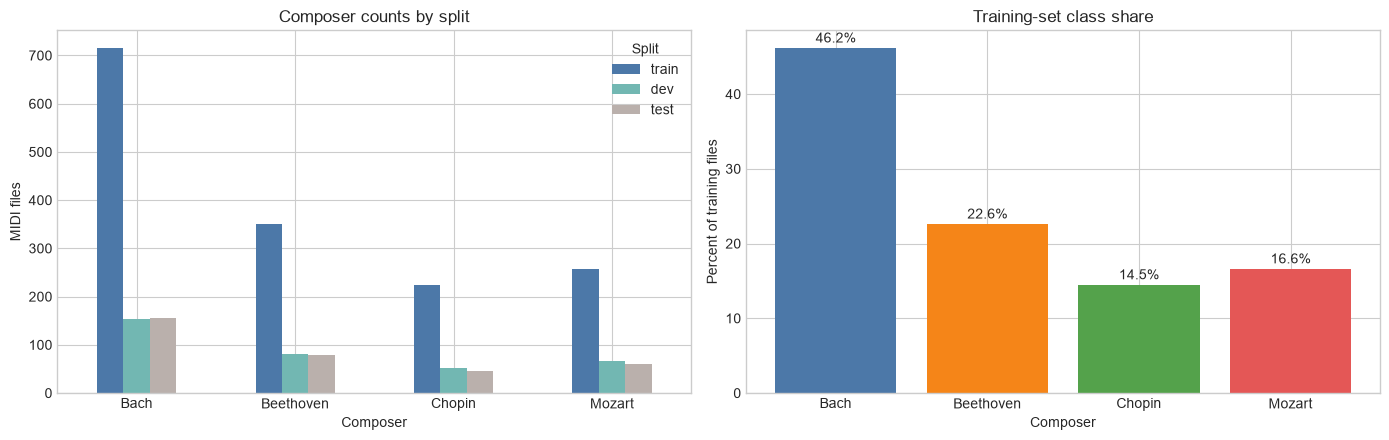

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

split_summary.T.plot(kind="bar", ax=axes[0], color=["#4C78A8", "#72B7B2", "#BAB0AC"])
axes[0].set_title("Composer counts by split")
axes[0].set_xlabel("Composer")
axes[0].set_ylabel("MIDI files")
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(title="Split")

train_share = train_df["composer"].value_counts(normalize=True).reindex(COMPOSER_ORDER) * 100
axes[1].bar(train_share.index, train_share.values, color=[COLORS[composer] for composer in train_share.index])
axes[1].set_title("Training-set class share")
axes[1].set_xlabel("Composer")
axes[1].set_ylabel("Percent of training files")
axes[1].tick_params(axis="x", rotation=0)
for index, value in enumerate(train_share.values):
    axes[1].text(index, value + 0.7, f"{value:.1f}%", ha="center")

fig.tight_layout()
plt.show()

## 4. Global timing and note-content distributions

These charts use the training split to show the distributions that the model will learn from.

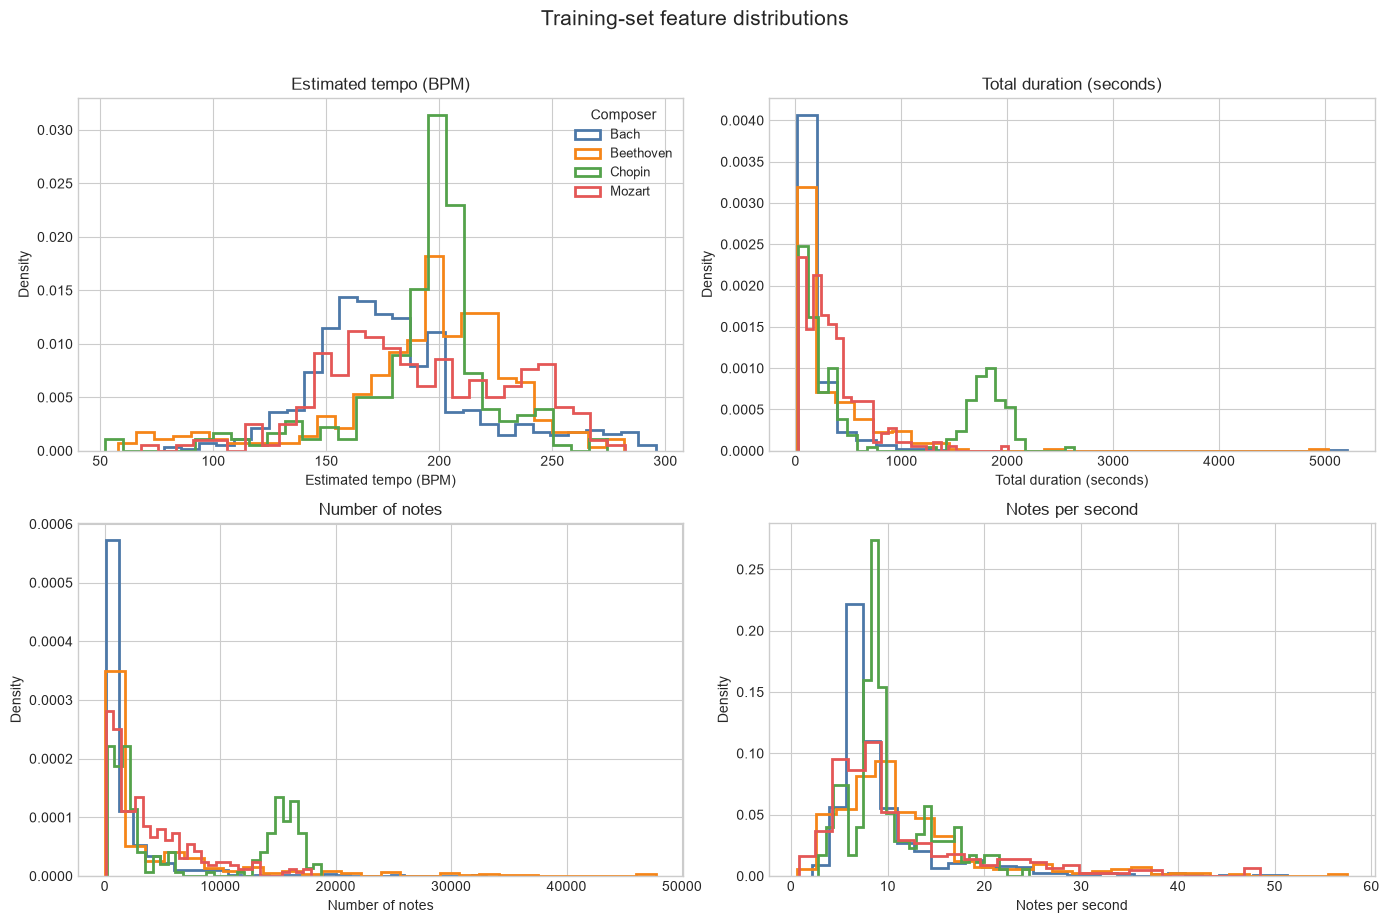

In [5]:
plot_features = [
    ("tempo", "Estimated tempo (BPM)"),
    ("total_duration", "Total duration (seconds)"),
    ("num_notes", "Number of notes"),
    ("note_density", "Notes per second"),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for axis, (feature, label) in zip(axes.flat, plot_features):
    for composer in COMPOSER_ORDER:
        values = train_df.loc[train_df["composer"] == composer, feature].dropna()
        axis.hist(values, bins=28, density=True, histtype="step", linewidth=2, label=composer, color=COLORS[composer])
    axis.set_title(label)
    axis.set_xlabel(label)
    axis.set_ylabel("Density")

axes[0, 0].legend(title="Composer", fontsize=9)
fig.suptitle("Training-set feature distributions", fontsize=15, y=1.02)
fig.tight_layout()
plt.show()

## 5. Composer comparison: pitch, rhythm, and texture

Each boxplot compares complete MIDI files in the training split. The center line is the median; the box contains the middle 50% of files; whiskers show the typical spread. Outliers are hidden to keep the central distributions readable.

### How to read the scales

- **Average pitch:** MIDI note number. Middle C is 60; one whole number equals one semitone. For example, 72 is C5, one octave above middle C.
- **Pitch standard deviation:** spread of note pitches, measured in semitones. A value of 12 means pitches typically vary by roughly one octave around the file's average pitch.
- **Median note duration:** seconds; the middle note length in a MIDI file.
- **Mean onset interval:** seconds between consecutive note starts. Smaller values mean notes begin more frequently.
- **Maximum polyphony:** the largest number of notes sounding at the same instant anywhere in the file.
- **Average polyphony:** the time-weighted average number of simultaneously sounding notes across the whole file.

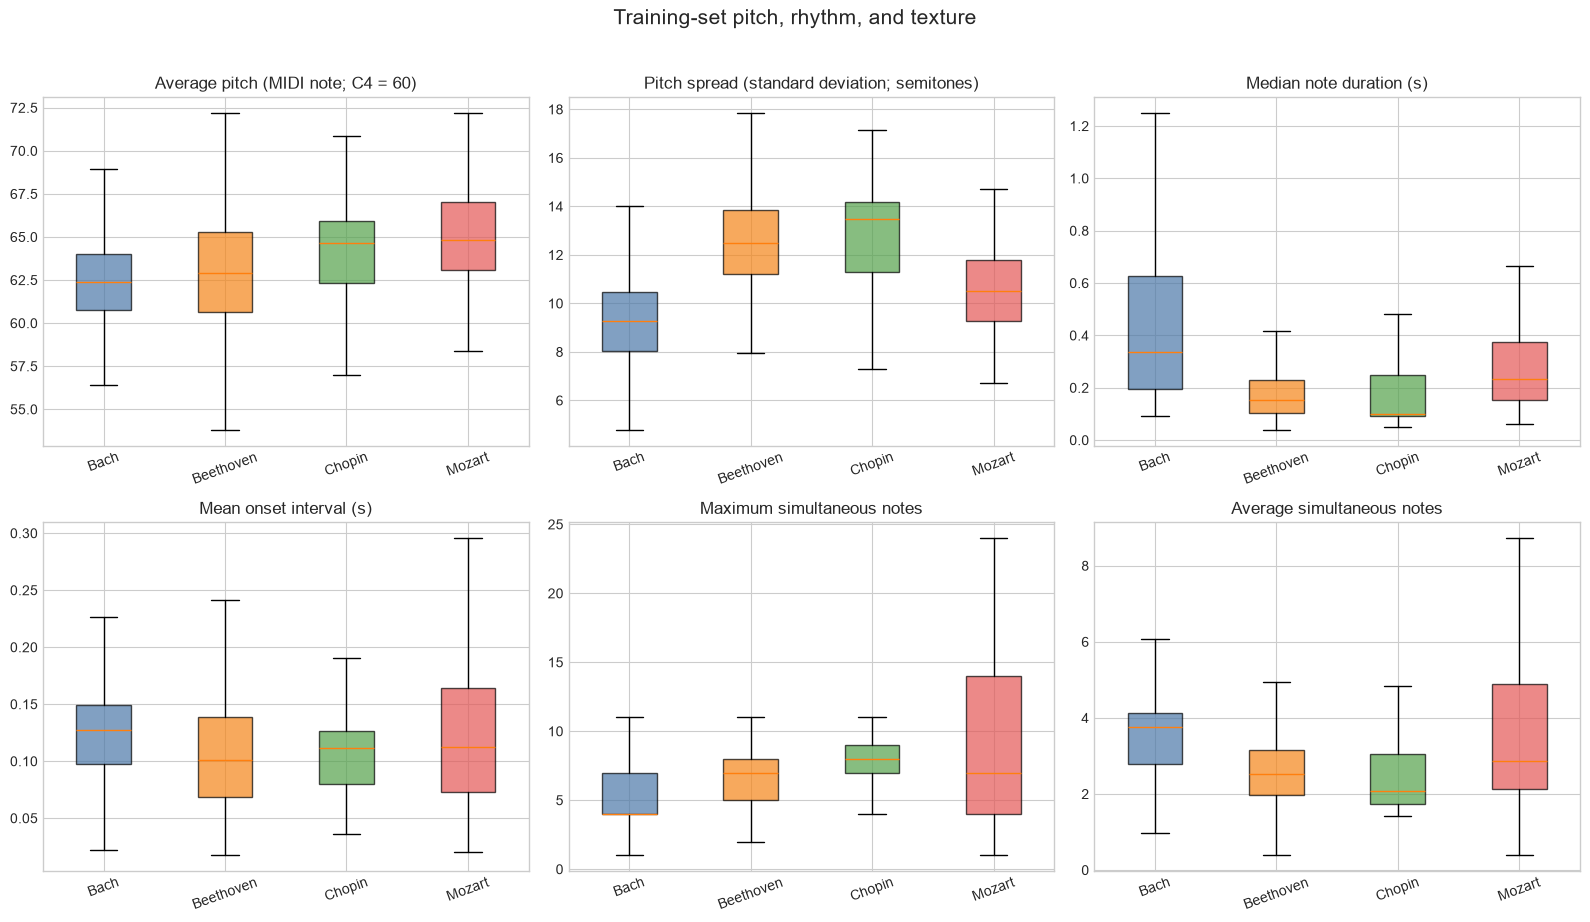

In [6]:
comparison_features = [
    ("avg_pitch", "Average pitch (MIDI note; C4 = 60)"),
    ("pitch_std", "Pitch spread (standard deviation; semitones)"),
    ("duration_median", "Median note duration (s)"),
    ("onset_interval_mean", "Mean onset interval (s)"),
    ("max_polyphony", "Maximum simultaneous notes"),
    ("avg_polyphony", "Average simultaneous notes"),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for axis, (feature, label) in zip(axes.flat, comparison_features):
    values = [train_df.loc[train_df["composer"] == composer, feature].dropna() for composer in COMPOSER_ORDER]
    boxplot = axis.boxplot(values, tick_labels=COMPOSER_ORDER, patch_artist=True, showfliers=False)
    for patch, composer in zip(boxplot["boxes"], COMPOSER_ORDER):
        patch.set_facecolor(COLORS[composer])
        patch.set_alpha(0.7)
    axis.set_title(label)
    axis.tick_params(axis="x", rotation=20)

fig.suptitle("Training-set pitch, rhythm, and texture", fontsize=15, y=1.02)
fig.tight_layout()
plt.show()

## 6. Instrumentation and track structure

General MIDI program assignments are imperfect metadata, but they can describe the arrangement choices represented in the source files.

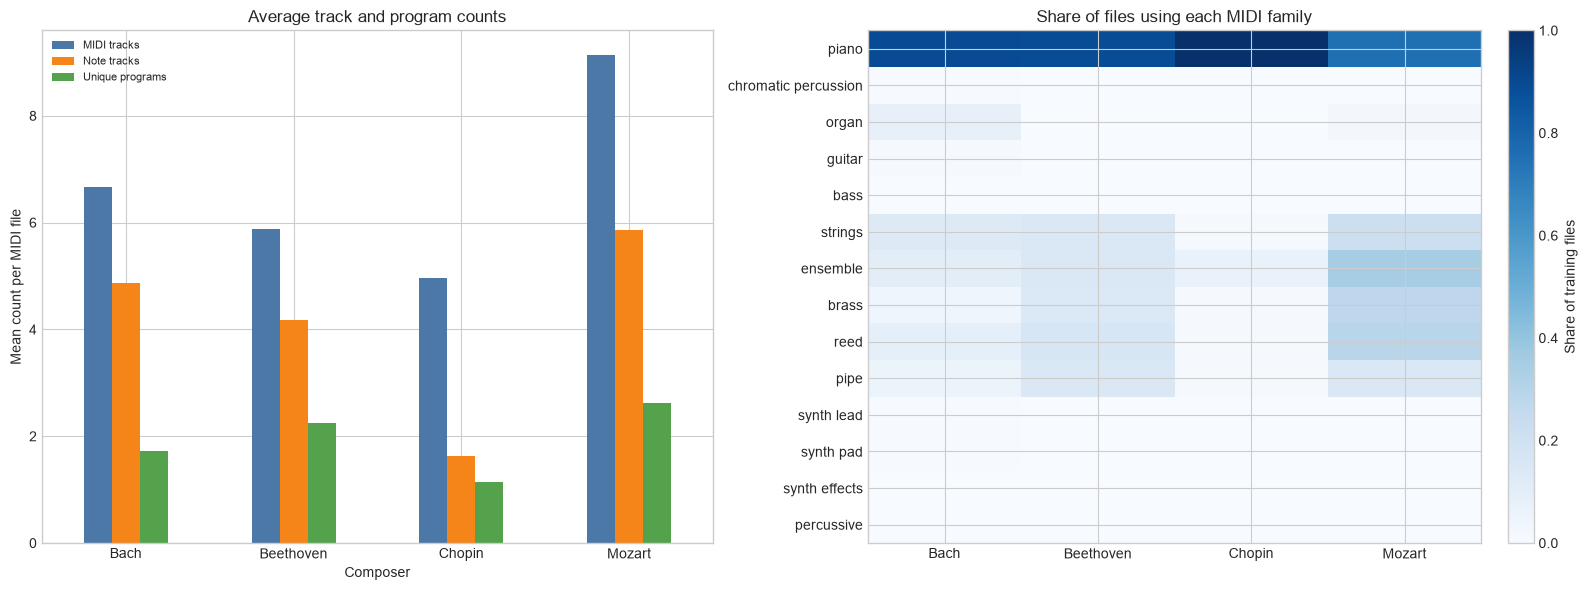

In [7]:
instrument_presence = (
    train_df.groupby("composer", observed=True)[INSTRUMENT_COLUMNS]
            .apply(lambda group: (group > 0).mean())
            .reindex(COMPOSER_ORDER)
)
active_instrument_columns = instrument_presence.columns[instrument_presence.sum() > 0]
instrument_presence = instrument_presence[active_instrument_columns]

short_labels = [column.removeprefix("gm_").removesuffix("_track_count").replace("_", " ") for column in active_instrument_columns]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

track_summary = train_df.groupby("composer", observed=True)[["num_midi_tracks", "num_note_tracks", "num_unique_programs"]].mean().reindex(COMPOSER_ORDER)
track_summary.plot(kind="bar", ax=axes[0], color=["#4C78A8", "#F58518", "#54A24B"])
axes[0].set_title("Average track and program counts")
axes[0].set_xlabel("Composer")
axes[0].set_ylabel("Mean count per MIDI file")
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(["MIDI tracks", "Note tracks", "Unique programs"], fontsize=8)

image = axes[1].imshow(instrument_presence.T, aspect="auto", cmap="Blues", vmin=0, vmax=1)
axes[1].set_title("Share of files using each MIDI family")
axes[1].set_xticks(range(len(COMPOSER_ORDER)), COMPOSER_ORDER)
axes[1].set_yticks(range(len(short_labels)), short_labels)
colorbar = fig.colorbar(image, ax=axes[1], fraction=0.046, pad=0.04)
colorbar.set_label("Share of training files")

fig.tight_layout()
plt.show()

## 7. Composer feature profile

This heatmap standardizes selected training-set means across composers. It emphasizes relative stylistic differences rather than differences in feature units.

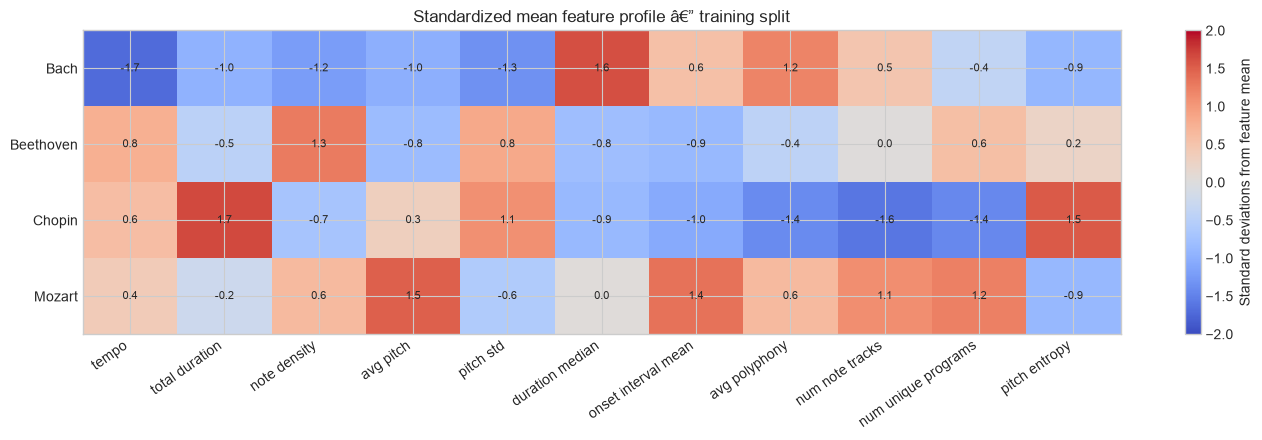

In [8]:
profile_features = [
    "tempo", "total_duration", "note_density", "avg_pitch", "pitch_std",
    "duration_median", "onset_interval_mean", "avg_polyphony",
    "num_note_tracks", "num_unique_programs", "pitch_entropy",
]
composer_profile = train_df.groupby("composer", observed=True)[profile_features].mean().reindex(COMPOSER_ORDER)
profile_zscores = (composer_profile - composer_profile.mean()) / composer_profile.std(ddof=0).replace(0, 1)

fig, axis = plt.subplots(figsize=(14, 4.5))
image = axis.imshow(profile_zscores, aspect="auto", cmap="coolwarm", vmin=-2, vmax=2)
axis.set_xticks(range(len(profile_features)), [feature.replace("_", " ") for feature in profile_features], rotation=35, ha="right")
axis.set_yticks(range(len(COMPOSER_ORDER)), COMPOSER_ORDER)
axis.set_title("Standardized mean feature profile â€” training split")
for row_index in range(len(COMPOSER_ORDER)):
    for column_index in range(len(profile_features)):
        axis.text(column_index, row_index, f"{profile_zscores.iloc[row_index, column_index]:.1f}", ha="center", va="center", fontsize=8)
fig.colorbar(image, ax=axis, label="Standard deviations from feature mean")
fig.tight_layout()
plt.show()

## 8. Feature redundancy and train-only separation ranking

Highly correlated features may be redundant. The F statistic below is a univariate training-only screen: it identifies potentially useful features but does not replace cross-validated model evaluation.

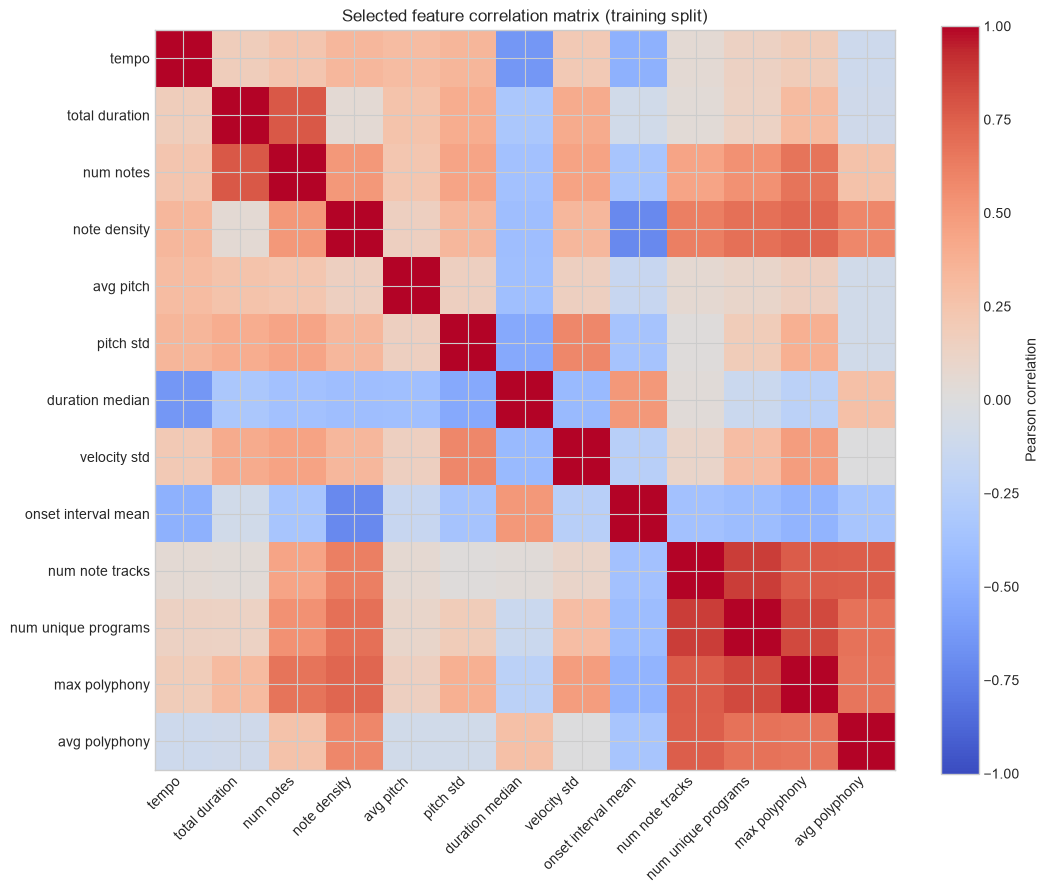

,feature,anova_f_score
0,velocity_range,604.919
1,velocity_std,510.069
2,range_normalized,433.414
3,pitch_range,423.055
4,pitch_std,270.229
5,avg_velocity,182.688
6,pitch_entropy,150.800
7,num_chords,147.822
8,total_duration,142.899
9,tempo_note_ratio,118.855


In [9]:
correlation_features = [
    "tempo", "total_duration", "num_notes", "note_density", "avg_pitch",
    "pitch_std", "duration_median", "velocity_std", "onset_interval_mean",
    "num_note_tracks", "num_unique_programs", "max_polyphony", "avg_polyphony",
]
correlation = train_df[correlation_features].corr()

fig, axis = plt.subplots(figsize=(11, 9))
image = axis.imshow(correlation, cmap="coolwarm", vmin=-1, vmax=1)
axis.set_xticks(range(len(correlation_features)), [feature.replace("_", " ") for feature in correlation_features], rotation=45, ha="right")
axis.set_yticks(range(len(correlation_features)), [feature.replace("_", " ") for feature in correlation_features])
axis.set_title("Selected feature correlation matrix (training split)")
fig.colorbar(image, ax=axis, label="Pearson correlation")
fig.tight_layout()
plt.show()

def anova_f_score(frame, feature, target="composer"):
    groups = [group[feature].dropna().to_numpy() for _, group in frame.groupby(target, observed=True)]
    groups = [group for group in groups if len(group) > 1]
    overall_mean = frame[feature].mean()
    between = sum(len(group) * (group.mean() - overall_mean) ** 2 for group in groups)
    within = sum(((group - group.mean()) ** 2).sum() for group in groups)
    degrees_between = len(groups) - 1
    degrees_within = sum(len(group) for group in groups) - len(groups)
    return (between / degrees_between) / (within / degrees_within) if within > 0 else np.nan

ranked_features = pd.DataFrame(
    {
        "feature": MODEL_FEATURES,
        "anova_f_score": [anova_f_score(train_df, feature) for feature in MODEL_FEATURES],
    }
).sort_values("anova_f_score", ascending=False)

display(ranked_features.head(15).reset_index(drop=True))